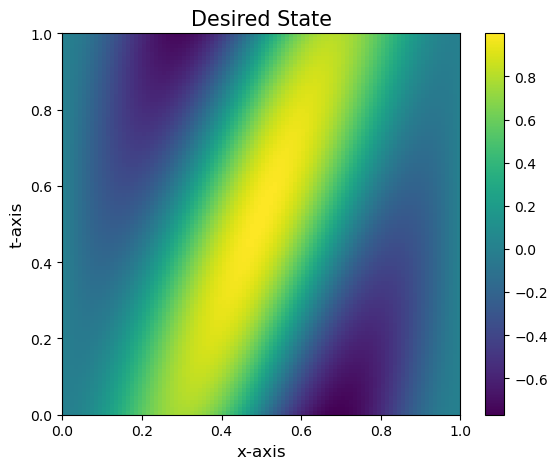

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.sparse as sparse
import scipy.sparse.linalg as spla
# ------------------------
# Function to solve Heat Equation OCP 
# Inputs:
#   alpha_reg     - Regularisation parameter
#   max_iter      - Maximum number of gradient descent iterations
#   tol           - Tolerance for the stopping criterion
#   gamma         - Armijo line search parameter
# Outputs:
#   x             - spatial grid
#   t             - temporal grid
#   U             - matrix storing the optimal control
#   Y             - matrix storing the optimal state
#   J_history     - list of cost functional values per iteration
#   L2_error_time - list of sptatial errors over time
# ------------------------

# ------------------------
# Domain and Mesh Parameters
# ------------------------
L, T = 1.0, 1.0  
Nx, Nt = 100, 100  
dx = L / (Nx - 1)
delta = T / Nt
nu = 1.0          # Diffusion coefficient
ua, ub = -10, 10  # Control constraints

# ------------------------
# Spatial and Temporal Meshes
# ------------------------
x = np.linspace(0, L, Nx)
t = np.linspace(0, T, Nt)
N_inner = Nx - 2  # We only solve for inner points (Dirichlet BCs)

# Create 2D coordinate grids for space and time
X, T_grid = np.meshgrid(x, t)

# Target is a sine wave that shifts to the right over time
Y_d = np.sin(2 * np.pi * X- 3*T_grid) * np.sin(np.pi * X)

def solve_heat_OCP(alpha_reg=0.01, max_iter=100, tol=1e-4, gamma=1e-4):

    # ------------------------
    # Diffusion Number (Stability Condition)
    # ------------------------
    r = nu * delta / (dx**2)
    
    # ------------------------
    # Backward Euler Difference Approximation
    # ------------------------
    main_diag = (1 + 2 * r) * np.ones(N_inner)
    off_diag = -r * np.ones(N_inner - 1)
    A = sparse.diags([off_diag, main_diag, off_diag], [-1, 0, 1], format='csc')

    # ------------------------
    # Forward State Solver
    # ------------------------
    def solve_state(u_in):
        Y = np.zeros((Nt, Nx))  # Initialises with Y[0, :] = 0 
        for mm in range(0, Nt - 1):
            # RHS: y_i^n + dt * u_i^n
            rhs = Y[mm, 1:-1] + delta * u_in[mm, 1:-1]
            # Solve A * y^{n+1} = rhs
            Y[mm + 1, 1:-1] = spla.spsolve(A, rhs)
        return Y

    # ------------------------
    # Backward Adjoint Solver
    # ------------------------
    def solve_adjoint(Y_in):
        P = np.zeros((Nt, Nx))  # Initialises terminal condition P[-1, :] = 0
        for mm in range(Nt - 2, -1, -1):
            # Source: y_i^n - y_d,i^n
            source = Y_in[mm, 1:-1] - Y_d[mm, 1:-1]
            # RHS: p_i^{n+1} + dt * source
            rhs = P[mm + 1, 1:-1] + delta * source
            # Solve A * p^n = rhs
            P[mm, 1:-1] = spla.spsolve(A, rhs)
        return P

    # ------------------------
    # Cost Functional
    # ------------------------
    def compute_cost(Y_in, u_in):
        state_cost = 0.5 * np.sum((Y_in - Y_d)**2) * dx * delta
        control_cost = 0.5 * alpha_reg * np.sum(u_in**2) * dx * delta
        return state_cost + control_cost

    # ------------------------
    # Initialisation for Optimisation
    # ------------------------
    U = np.zeros((Nt, Nx))
    Y = solve_state(U)
    Y_uncontrolled = Y.copy()
    current_J = compute_cost(Y, U)
    J_history = []

    # ------------------------
    # Optimisation Loop 
    # ------------------------
    for iter_num in range(max_iter):
        
        P = solve_adjoint(Y)
        
        # Gradient and descent direction
        grad = alpha_reg * U + P
        vn = -grad
        
        # Armijo Line Search
        sn = 50.0
        U_next = U.copy()
        
        while sn > 1e-10:
            U_trial = np.clip(U + sn * vn, ua, ub)
            Y_trial = solve_state(U_trial)
            J_trial = compute_cost(Y_trial, U_trial)

            diff_norm_sq = np.sum((U_trial - U)**2) * dx * delta
            
            # Armijo condition check
            if J_trial - current_J <= -gamma * diff_norm_sq:
                U_next = U_trial
                Y = Y_trial
                current_J = J_trial
                break
            
            sn *= 0.5  # Reduce step size 
        
        J_history.append(current_J)

        # Stopping Criterion
        diff_u_L2 = (1 / sn) * np.sqrt(np.sum((U_next - U)**2) * dx * delta)
        if diff_u_L2 < tol:
            U = U_next
            break
            
        U = U_next

    # ------------------------
    # Calculate Final Tracking Error Norm
    # ------------------------
    squared_error = (Y - Y_d)**2
    L2_error_time = np.sqrt(np.sum(squared_error, axis=1) * dx)
        
    return x, t, U, Y, J_history, L2_error_time

# ------------------------
# Plotting
# ------------------------
def plot_opti_graphs(x, y_d, u, y, J_history, alpha, T=1.0, L=1.0):
    # Set up the figure with two 2D subplots side-by-side
    fig, axs = plt.subplots(1, 2, figsize=(12, 5)) 
    
    # --- First Subplot: Optimal Control ---
    im1 = axs[0].imshow(u, extent=[0, L, 0, T], origin='lower', aspect='auto', cmap='viridis')
    fig.colorbar(im1, ax=axs[0])
    axs[0].set_title("Optimal Control", fontsize=15)
    axs[0].set_xlabel("x-axis", fontsize=12)
    axs[0].set_ylabel("t-axis", fontsize=12)

    # --- Second Subplot: Optimal State ---
    im2 = axs[1].imshow(y, extent=[0, L, 0, T], origin='lower', aspect='auto', cmap='viridis')
    fig.colorbar(im2, ax=axs[1])
    axs[1].set_title("Associated Optimal State", fontsize=15)
    axs[1].set_xlabel("x-axis", fontsize=12)
    axs[1].set_ylabel("t-axis", fontsize=12)

    plt.tight_layout() 
    #plt.savefig(f"optimal_results_alpha_{alpha}_heatmap.png", dpi=300, bbox_inches='tight')
    plt.show()

def plot_tracking_error_norm(t, L2_error_time):
    plt.figure(figsize=(7, 4))
    plt.plot(t, L2_error_time, linewidth=2, label=r'$\|y(\cdot, t) - y_d(\cdot, t)\|_{L^2(0,1)}$')
    plt.ylim(0.25, 0.55)
    plt.title("Spatial error tracking over time", fontsize=15)
    plt.xlabel("t-axis", fontsize=12)
    plt.ylabel("Error Norm", fontsize=12)
    plt.grid(True, linestyle='--', alpha=0.7)
    plt.legend(fontsize=12)
    plt.tight_layout()
    #plt.savefig(f"error_term_{alpha}_graph.png", dpi=300, bbox_inches='tight')
    plt.show()

def cost_table(J_hist, alpha):
    print("Iterations | Cost J")
    print("-" * 25)
    for i in range(0, len(J_hist), 1000): 
        print(f"{i:10d} | {J_hist[i]:.6f}")
    if len(J_hist) > 0:
        print(f"{len(J_hist)-1:10d} | {J_hist[-1]:.6f}")
        
# Plot desired state
plt.figure(figsize=(5.8, 4.8)) 
plt.imshow(Y_d, extent=[0, L, 0, T], origin='lower', aspect='auto', cmap='viridis')
plt.colorbar()
plt.title("Desired State", fontsize = 15)
plt.xlabel("x-axis", fontsize = 12)
plt.ylabel("t-axis", fontsize = 12)
plt.tight_layout()
#plt.savefig("desired_state_heatmap.png", dpi=300, bbox_inches='tight')
plt.show()


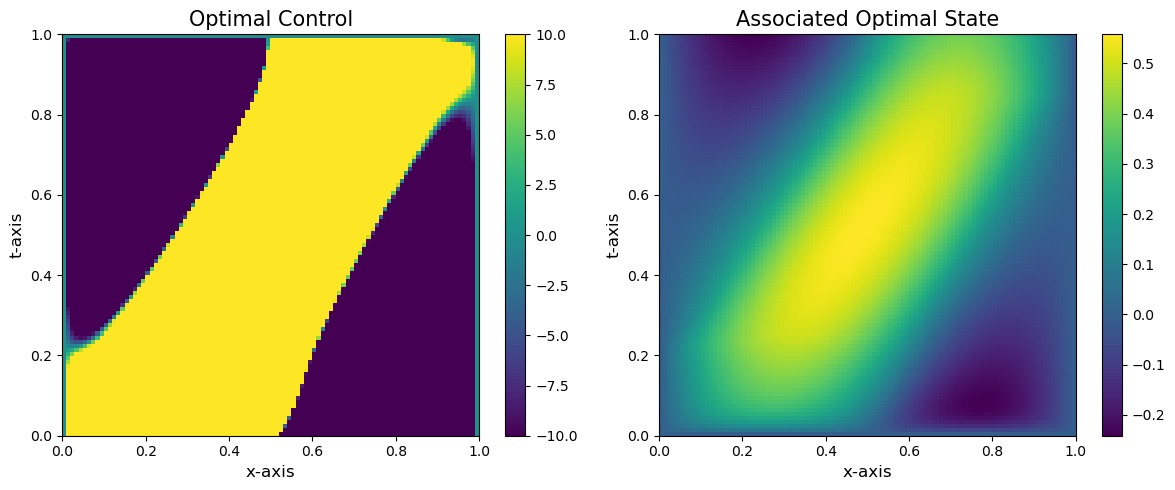

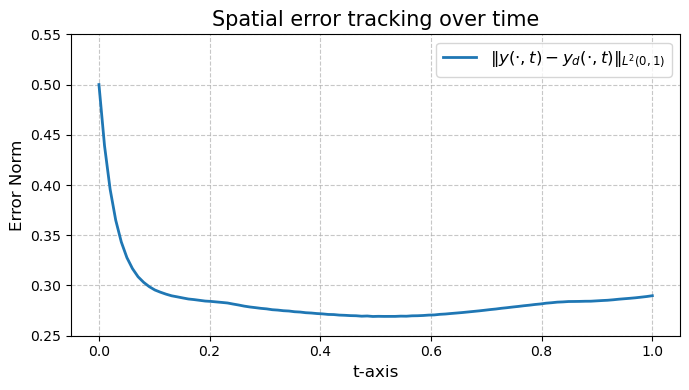

Iterations | Cost J
-------------------------
         0 | 0.098222
      1000 | 0.042092
      2000 | 0.042087
      3000 | 0.042086
      4000 | 0.042086
      4428 | 0.042086


In [2]:
# Implimentation  
alpha = 1e-5
max_iter = 6000
tol = 1e-6
gamma = 1e-4
x, t, u, y, J_hist, L2_error = solve_heat_OCP(alpha, max_iter, tol, gamma)
plot_opti_graphs(x, t, u, y, J_hist, alpha)
plot_tracking_error_norm(t, L2_error)
cost_table(J_hist, alpha)

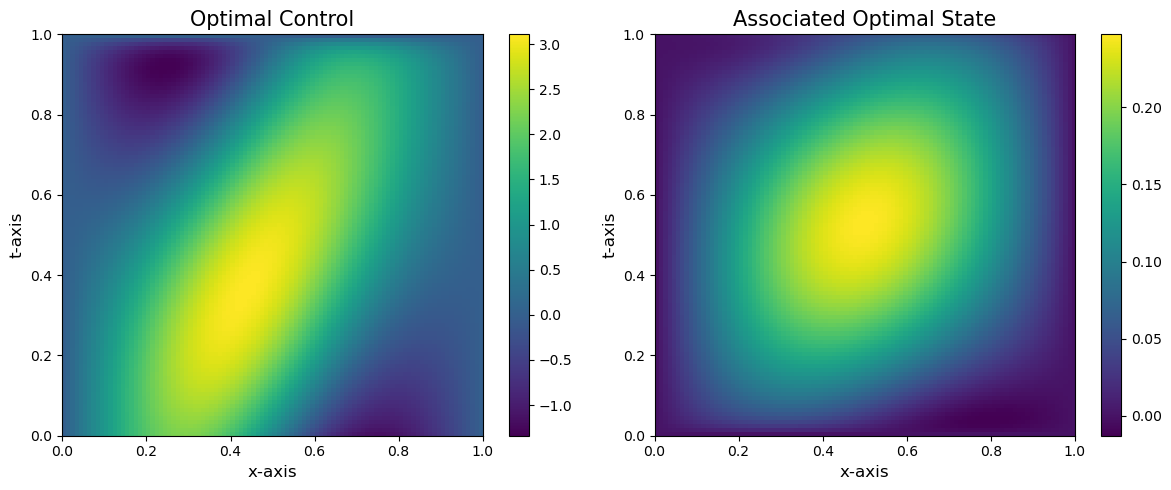

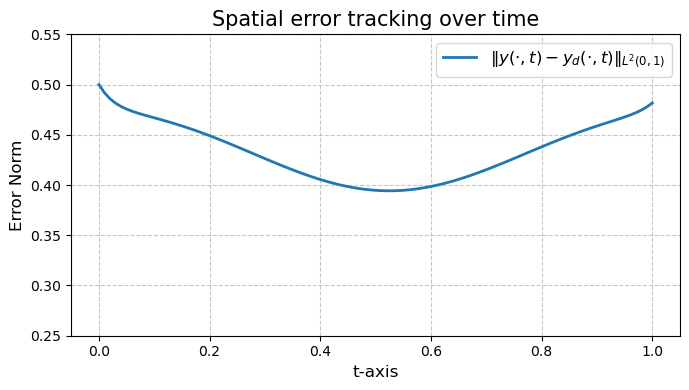

Iterations | Cost J
-------------------------
         0 | 0.106711
        12 | 0.105921


In [3]:
# Implimentation  
alpha = 1e-2
max_iter = 1000
tol = 1e-6
gamma = 1e-4
x, t, u, y, J_hist, L2_error = solve_heat_OCP(alpha, max_iter, tol, gamma)
plot_opti_graphs(x, t, u, y, J_hist, alpha)
plot_tracking_error_norm(t, L2_error)
cost_table(J_hist, alpha)